In [ ]:
# Import necessary libraries
import re
import asyncio
import aiohttp
from bs4 import BeautifulSoup
from pydantic import BaseModel
from typing import List, Dict
import nest_asyncio
import json
import datetime

# Apply nest_asyncio to allow running asyncio in notebook
nest_asyncio.apply()

# Request headers for all requests
req_headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/123.0.0.0 Safari/537.36',
    'Accept-Language': 'en-US, en;q=0.5'
}

# Precompiled regex pattern for seller info (for efficiency)
SELLER_INFO_REGEX = r'^(.*?)\s*\(([\d,]+)\)\s*([\d.]+%)$'

print("Setup complete!")

In [ ]:
def get_title(soup):
    try:
        title_tag = soup.find("h1", id="itemTitle")
        if title_tag:
            return title_tag.get_text(strip=True).replace("Details about  \xa0", "")
    except Exception:
        pass
    return ""

def get_price(soup):
    try:
        price_tag = soup.find("span", id="prcIsum")
        if not price_tag:
            price_tag = soup.find("span", id="mm-saleDscPrc")
        if price_tag:
            return price_tag.get_text(strip=True)
    except Exception:
        pass
    return ""

def get_images(soup):
    buttons = soup.find_all("button", class_="ux-image-grid-item image-treatment rounded-edges")
    images = []
    for btn in buttons:
        img = btn.find('img')
        if img and img.get('src'):
            images.append(img.get('src'))
    return images

def get_watchers(soup):
    try:
        divs = soup.find_all("div", class_="ux-section-icon-with-details__data-item-text")
        if divs:
            text = divs[0].text.strip()
            numbers = re.findall(r'\d+', text)
            return numbers[0] if numbers else ""
    except Exception:
        pass
    return ""

def get_condition(soup):
    try:
        condition_div = soup.find("div", class_='x-item-condition-text')
        if condition_div:
            span = condition_div.find("span", class_="clipped")
            if span:
                return span.text.strip()
    except Exception:
        pass
    return ""

def get_item_features(soup):
    features = {}
    try:
        container = soup.find("div", id="viTabs_0_is")
        if container:
            container = container.find("div", class_="ux-layout-section-evo__item ux-layout-section-evo__item--table-view")
            if container:
                rows = container.find_all("div", class_="ux-layout-section-evo__row")
                for row in rows:
                    dls = row.find_all("dl")
                    for dl in dls:
                        dt = dl.find("dt")
                        dd = dl.find("dd")
                        if dt and dd:
                            label = dt.get_text(strip=True)
                            value_container = dd.find("div", class_="ux-labels-values__values-content")
                            value = value_container.get_text(strip=True) if value_container else dd.get_text(strip=True)
                            features[label] = value
    except Exception:
        pass
    return features

print("Product detail extraction functions loaded!")

In [ ]:
def auction_get_title(item):
    try:
        return item.find("div", class_="s-item__title").text.strip()
    except Exception:
        return ""

def auction_get_price(item):
    try:
        return item.find("span", class_="s-item__price").text.strip()
    except Exception:
        return ""

def auction_get_bid_count(item):
    try:
        bid_elem = item.select_one("span.s-item__bids.s-item__bidCount")
        return bid_elem.text.strip() if bid_elem else ""
    except Exception:
        return ""

def auction_get_time_left(item):
    try:
        return item.find("span", class_="s-item__time-left").text.strip()
    except Exception:
        return ""

def auction_get_best_offer(item):
    try:
        bo_elem = item.select_one("div.s-item__dynamic.s-item__formatBestOfferEnabled a span")
        return bo_elem.text.strip() if bo_elem else ""
    except Exception:
        return ""

def auction_get_delivery_cost(item):
    try:
        delivery_elem = item.select_one("span.s-item__shipping.s-item__logisticsCost")
        return delivery_elem.text.strip() if delivery_elem else ""
    except Exception:
        return ""

def auction_get_authenticity(item):
    try:
        auth_elem = item.select_one("span.s-item__hotness.s-item__authorized-seller")
        return auth_elem.text.strip() if auth_elem else ""
    except Exception:
        return ""

def auction_get_product_image(item):
    try:
        image_wrapper = item.find("div", class_="s-item__image-wrapper image-treatment")
        if image_wrapper:
            img = image_wrapper.find("img")
            return img['src'].strip() if img and img.get('src') else ""
    except Exception:
        return ""
    return ""

def auction_get_product_link(item):
    try:
        a_tag = item.find("a", href=True)
        return a_tag['href'].strip() if a_tag else ""
    except Exception:
        return ""

def auction_get_seller_info(item):
    try:
        seller_info = item.find("span", class_="s-item__seller-info-text").text.strip()
    except AttributeError:
        seller_info = ""
    return seller_info

def parse_seller_info(seller_info):
    """
    Uses a precompiled regex for efficiency.
    Expected format: "seller_name (number) rating"
    """
    match = re.search(SELLER_INFO_REGEX, seller_info)
    if match:
        seller_name = match.group(1).strip()
        seller_no_reviews = match.group(2).replace(',', '')
        seller_rating = match.group(3)
        return seller_name, seller_no_reviews, seller_rating
    return seller_info, "", ""

print("Auction listing extraction functions loaded!")

In [ ]:
async def fetch_page(session: aiohttp.ClientSession, url: str, headers: dict) -> str:
    async with session.get(url, headers=headers, timeout=10) as response:
        if response.status != 200:
            raise Exception(f"Error fetching {url}: Status code {response.status}")
        return await response.text()

print("Async fetch function loaded!")

In [ ]:
async def search_auctions(search_term: str = "iphone", pages: int = 1):
    """
    Asynchronously search eBay auctions for a given search term across the specified number of pages.
    Returns detailed auction data concurrently.
    """
    tasks = []
    async with aiohttp.ClientSession() as session:
        for page in range(1, pages + 1):
            search_url = f'https://www.ebay.com/sch/i.html?_nkw={search_term}&LH_Auction=1&_pgn={page}'
            tasks.append(fetch_page(session, search_url, req_headers))
        pages_content = await asyncio.gather(*tasks)
    
    auctions = []
    for content in pages_content:
        # Parse the HTML content
        soup = BeautifulSoup(content, "html.parser")
        items = soup.find_all("li", class_="s-item s-item__pl-on-bottom")
        for item in items:
            title = auction_get_title(item)
            if not title or title == "Shop on eBay":
                continue
            price = auction_get_price(item)
            product_link = auction_get_product_link(item)
            bid_count = auction_get_bid_count(item)
            time_left = auction_get_time_left(item)
            best_offer = auction_get_best_offer(item)
            delivery_cost = auction_get_delivery_cost(item)
            authenticity = auction_get_authenticity(item)
            product_image = auction_get_product_image(item)
            seller_info_raw = auction_get_seller_info(item)
            seller_name, seller_no_reviews, seller_rating = parse_seller_info(seller_info_raw)
            
            auctions.append({
                "title": title,
                "price": price,
                "product_link": product_link,
                "bid_count": bid_count,
                "time_left": time_left,
                "best_offer": best_offer,
                "delivery_cost": delivery_cost,
                "authenticity": authenticity,
                "product_image": product_image,
                "seller_info": seller_info_raw,
                "seller_name": seller_name,
                "seller_no_reviews": seller_no_reviews,
                "seller_rating": seller_rating
            })
    
    return auctions

print("Search auctions function loaded!")

In [ ]:
async def fetch_product_data(url: str, headers: dict = req_headers) -> dict:
    try:
        async with aiohttp.ClientSession() as session:
            async with session.get(url, headers=headers, timeout=10) as response:
                if response.status != 200:
                    return {"product_link": url, "error": f"Status code {response.status}"}
                html = await response.text()
                # Parse the content
                soup = BeautifulSoup(html, "html.parser")
                return {
                    "title": get_title(soup),
                    "price": get_price(soup),
                    "images": get_images(soup),
                    "watchers": get_watchers(soup),
                    "condition": get_condition(soup),
                    "item_features": get_item_features(soup),
                    "product_link": url
                }
    except Exception as e:
        return {"product_link": url, "error": str(e)}

print("Product data fetch function loaded!")

In [ ]:
# Run a sample search for "vintage watch"
async def run_sample_search():
    results = await search_auctions("vintage watch", pages=1)
    print(f"Found {len(results)} auctions")
    
    # Display first 3 results
    for i, result in enumerate(results[:3], 1):
        print(f"\nResult {i}:")
        print(f"Title: {result['title']}")
        print(f"Price: {result['price']}")
        print(f"Bids: {result['bid_count']}")
        print(f"Time left: {result['time_left']}")
        print(f"Seller: {result['seller_name']}")
        print(f"Link: {result['product_link']}")
    
    return results

# Execute the search
search_results = await run_sample_search()

In [ ]:
async def get_product_details():
    # Use the first product link from our search results
    if not search_results or len(search_results) == 0:
        print("No search results available. Run the search first.")
        return
    
    product_link = search_results[0]['product_link']
    print(f"Fetching details for: {search_results[0]['title']}")
    
    details = await fetch_product_data(product_link)
    
    print("\nProduct Details:")
    print(f"Title: {details.get('title', 'N/A')}")
    print(f"Price: {details.get('price', 'N/A')}")
    print(f"Condition: {details.get('condition', 'N/A')}")
    print(f"Watchers: {details.get('watchers', 'N/A')}")
    print(f"Number of images: {len(details.get('images', []))}")
    
    print("\nFeatures:")
    for key, value in details.get('item_features', {}).items():
        print(f"- {key}: {value}")
    
    return details

# Execute to get product details
product_details = await get_product_details()

In [18]:
async def find_highest_bid_count_auctions(search_term="sony 24-70 gm", pages=2):
    results = await search_auctions(search_term, pages)
    
    # Filter out items with no bid count
    items_with_bids = []
    for item in results:
        if item['bid_count']:
            try:
                # Extract number from bid text (e.g., "5 bids" -> 5)
                bid_count = int(re.search(r'\d+', item['bid_count']).group())
                item['bid_count_num'] = bid_count
                items_with_bids.append(item)
            except (AttributeError, ValueError):
                continue
    
    # Sort by bid count (highest first)
    sorted_items = sorted(items_with_bids, key=lambda x: x['time_left'], reverse=False)
    
    print(f"\nTop 5 Most Popular {search_term} Auctions (by bid count):")
    for i, item in enumerate(sorted_items[:10], 1):
        print(f"{i}. {item['title']} - {item['price']} - {item['bid_count']} - {item['time_left']}")
    
    return sorted_items

# Execute to find popular auctions
popular_auctions = await find_highest_bid_count_auctions("sony 24-70 gm")


Top 5 Most Popular sony 24-70 gm Auctions (by bid count):
1. Sony FE 70-200mm F/2.8 GM OSS II Lens SEL70200GM2 - $1,655.00 - 7 bids · - 1d 2h left
2. Sony FE 70-200mm F/2.8 GM OSS II Lens SEL70200GM2 - $1,655.00 - 7 bids · - 1d 2h left
3. Sony SEL E Mount 70200GM FE 70-200mm F2.8 GM OS Lens - White - $1,699.00 - 0 bids · - 1d 6h left
4. Sony SEL E Mount 70200GM FE 70-200mm F2.8 GM OS Lens - White - $1,699.00 - 0 bids · - 1d 6h left
5. Sony G Master FE 24-70 mm F2.8 GM Full-Frame E-Mount Standard Zoom Lens USED - $895.00 - 0 bids · - 2d 9h left
6. Sony G Master FE 24-70 mm F2.8 GM Full-Frame E-Mount Standard Zoom Lens USED - $895.00 - 0 bids · - 2d 9h left
7. Sony FE 24-70mm f/2.8 GM (SEL2470GM) Full-Frame E-Mount Lens - Mint Condition - $856.00 - 48 bids · - 2h 22m left
8. Sony FE 24-70mm f/2.8 GM (SEL2470GM) Full-Frame E-Mount Lens - Mint Condition - $856.00 - 48 bids · - 2h 22m left
9. Box - $50.00 - 0 bids · - 3d 23h left
10. Box - $50.00 - 0 bids · - 3d 23h left


In [ ]:
def save_to_json(data, filename="ebay_results.json"):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Data saved to {filename}")

# Save our search results
save_to_json(search_results, "vintage_watches.json")

# Adding a database

In [19]:
import sqlite3
from urllib.parse import urlparse, parse_qs

In [20]:
# Function to extract eBay item ID from product link
def extract_item_id(product_link):
    """Extract the unique item ID from an eBay product URL"""
    try:
        # Parse the URL and query string
        parsed_url = urlparse(product_link)
        
        # Try to find item ID in path (e.g., /itm/123456789)
        path_match = re.search(r'/itm/(\d+)', parsed_url.path)
        if path_match:
            return path_match.group(1)
        
        # Try to find item ID in query parameters
        query_params = parse_qs(parsed_url.query)
        if 'item' in query_params:
            return query_params['item'][0]
        
        # If no ID found, use the full URL as a fallback
        return product_link
    except:
        return product_link

# Function to extract numeric price
def extract_numeric_price(price_str):
    """Convert price string like '$49.99' to numeric value 49.99"""
    if not price_str:
        return None
    
    try:
        # Remove currency symbols, commas, and other non-numeric chars except decimal point
        cleaned = re.sub(r'[^\d.]', '', price_str)
        return float(cleaned) if cleaned else None
    except ValueError:
        return None

# Initialize database
def init_database():
    """Create the SQLite database and tables if they don't exist"""
    conn = sqlite3.connect('ebay_auction_tracker.db')
    cursor = conn.cursor()
    
    # Create items table to store unique items
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS items (
        item_id TEXT PRIMARY KEY,
        first_seen_title TEXT,
        first_seen_date TEXT,
        search_term TEXT
    )
    ''')
    
    # Create observations table to store price history
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS observations (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        item_id TEXT,
        title TEXT,
        price TEXT,
        price_numeric REAL,
        bid_count TEXT,
        bid_count_numeric INTEGER,
        time_left TEXT,
        seller_name TEXT,
        product_link TEXT,
        observation_date TEXT,
        FOREIGN KEY (item_id) REFERENCES items (item_id)
    )
    ''')
    
    conn.commit()
    return conn


In [21]:
# Record search results to database
async def record_search_results(search_term, pages=2, conn=None):
    """Search for items and record results to database"""
    # Get the connection if not provided
    if conn is None:
        conn = init_database()
    
    cursor = conn.cursor()
    current_time = datetime.datetime.now().isoformat()
    
    # Perform the search
    print(f"Searching for '{search_term}' ({pages} pages)")
    results = await search_auctions(search_term, pages)
    print(f"Found {len(results)} auctions")
    
    # Counter for new and updated items
    new_items = 0
    updated_items = 0
    
    # Process each auction result
    for item in results:
        # Extract the item ID from the product link
        item_id = extract_item_id(item['product_link'])
        
        # Check if this item exists in our database
        cursor.execute("SELECT * FROM items WHERE item_id = ?", (item_id,))
        existing_item = cursor.fetchone()
        
        if not existing_item:
            # New item, add to items table
            cursor.execute(
                "INSERT INTO items (item_id, first_seen_title, first_seen_date, search_term) VALUES (?, ?, ?, ?)",
                (item_id, item['title'], current_time, search_term)
            )
            new_items += 1
        
        # Extract numeric values
        price_numeric = extract_numeric_price(item['price'])
        
        # Extract bid count numeric
        bid_count_numeric = None
        if item['bid_count']:
            try:
                bid_count_numeric = int(re.search(r'\d+', item['bid_count']).group())
            except (AttributeError, ValueError):
                pass
        
        # Add observation to observations table
        cursor.execute('''
        INSERT INTO observations 
        (item_id, title, price, price_numeric, bid_count, bid_count_numeric, 
         time_left, seller_name, product_link, observation_date)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            item_id, item['title'], item['price'], price_numeric,
            item['bid_count'], bid_count_numeric, item['time_left'],
            item['seller_name'], item['product_link'], current_time
        ))
        updated_items += 1
    
    # Commit changes
    conn.commit()
    print(f"Recorded {new_items} new items and {updated_items} total observations")
    
    return results

# Run tracking for multiple search terms
async def track_multiple_searches(search_terms, pages=2):
    """Track multiple search terms and record to database"""
    conn = init_database()
    
    for term in search_terms:
        await record_search_results(term, pages, conn)
    
    conn.close()
    print(f"Completed tracking {len(search_terms)} search terms")

# Schedule regular tracking
async def scheduled_tracking(search_terms, interval_hours=1, pages=2):
    """Run tracking at regular intervals"""
    while True:
        start_time = datetime.datetime.now()
        print(f"\n--- Starting scheduled tracking at {start_time.strftime('%Y-%m-%d %H:%M:%S')} ---")
        
        try:
            await track_multiple_searches(search_terms, pages)
        except Exception as e:
            print(f"Error during tracking: {e}")
        
        # Calculate time to next run
        elapsed = (datetime.datetime.now() - start_time).total_seconds()
        sleep_seconds = max(1, interval_hours * 3600 - elapsed)  # At least 1 second
        
        next_run = datetime.datetime.now() + datetime.timedelta(seconds=sleep_seconds)
        print(f"Next run scheduled for {next_run.strftime('%Y-%m-%d %H:%M:%S')}")
        
        # Sleep until next run
        await asyncio.sleep(sleep_seconds)

# Get price history for a specific item
def get_item_price_history(item_id=None, product_link=None):
    """Get price history for an item from the database"""
    conn = sqlite3.connect('ebay_auction_tracker.db')
    cursor = conn.cursor()
    
    # If product link provided but not item_id
    if not item_id and product_link:
        item_id = extract_item_id(product_link)
    
    if not item_id:
        print("Error: Must provide either item_id or product_link")
        return None
    
    # Query the database
    cursor.execute('''
    SELECT observation_date, price, price_numeric, bid_count_numeric, time_left
    FROM observations
    WHERE item_id = ?
    ORDER BY observation_date
    ''', (item_id,))
    
    history = cursor.fetchall()
    
    # Get item details
    cursor.execute('SELECT first_seen_title, search_term FROM items WHERE item_id = ?', (item_id,))
    item_details = cursor.fetchone()
    
    conn.close()
    
    if not history:
        print(f"No history found for item ID {item_id}")
        return None
    
    print(f"Price history for: {item_details[0] if item_details else 'Unknown'}")
    print(f"Item ID: {item_id}")
    print(f"Search term: {item_details[1] if item_details else 'Unknown'}")
    print("\nDate                 | Price      | Bids | Time Left")
    print("-" * 60)
    
    for date, price, price_num, bids, time_left in history:
        date_str = date.split('T')[0] + ' ' + date.split('T')[1][:8]  # Format datetime
        print(f"{date_str} | {price:10s} | {bids if bids else 'N/A':4} | {time_left if time_left else 'N/A'}")
    
    return history


In [22]:
# Function to generate a summary report
def generate_summary_report():
    """Generate a summary report of all tracked items"""
    conn = sqlite3.connect('ebay_auction_tracker.db')
    cursor = conn.cursor()
    
    # Get count of unique items
    cursor.execute("SELECT COUNT(*) FROM items")
    item_count = cursor.fetchone()[0]
    
    # Get count of observations
    cursor.execute("SELECT COUNT(*) FROM observations")
    observation_count = cursor.fetchone()[0]
    
    # Get items with most price changes
    cursor.execute('''
    SELECT i.first_seen_title, i.item_id, COUNT(o.id) as num_observations,
           MIN(o.price_numeric) as min_price, MAX(o.price_numeric) as max_price,
           (MAX(o.price_numeric) - MIN(o.price_numeric)) as price_change
    FROM items i
    JOIN observations o ON i.item_id = o.item_id
    GROUP BY i.item_id
    HAVING COUNT(o.id) > 1 AND MIN(o.price_numeric) IS NOT NULL AND MAX(o.price_numeric) IS NOT NULL
    ORDER BY price_change DESC
    LIMIT 10
    ''')
    
    changing_items = cursor.fetchall()
    
    # Get items with most bid activity
    cursor.execute('''
    SELECT i.first_seen_title, i.item_id, MAX(o.bid_count_numeric) as max_bids
    FROM items i
    JOIN observations o ON i.item_id = o.item_id
    WHERE o.bid_count_numeric IS NOT NULL
    GROUP BY i.item_id
    ORDER BY max_bids DESC
    LIMIT 10
    ''')
    
    popular_items = cursor.fetchall()
    
    conn.close()
    
    # Print the report
    print("\n===== eBay Auction Tracker Summary Report =====")
    print(f"Total tracked items: {item_count}")
    print(f"Total observations: {observation_count}")
    
    print("\nItems with Most Price Movement:")
    print("Title                                          | Min Price | Max Price | Change")
    print("-" * 80)
    for title, item_id, obs_count, min_price, max_price, change in changing_items:
        # Truncate long titles
        short_title = title[:40] + "..." if len(title) > 40 else title.ljust(43)
        print(f"{short_title} | ${min_price:.2f}    | ${max_price:.2f}    | ${change:.2f}")
    
    print("\nMost Popular Items (by bid count):")
    print("Title                                          | Max Bids")
    print("-" * 60)
    for title, item_id, max_bids in popular_items:
        # Truncate long titles
        short_title = title[:40] + "..." if len(title) > 40 else title.ljust(43)
        print(f"{short_title} | {max_bids}")
    
    print("\n============================================")


In [23]:
# Examples of how to use these functions in a Jupyter notebook
import asyncio

# This allows using await at the top level in Jupyter notebooks
import nest_asyncio
nest_asyncio.apply()

# Define your search terms
search_terms = ["sony 24-70 gm", "vintage omega watch", "macbook pro 16", "sony 200mm"]
    
# Initialize the database
init_database()

# Function to run one-time tracking
async def run_one_time_tracking():
    print("--- One-time tracking ---")
    await track_multiple_searches(search_terms, pages=1)
    
    # Generate a summary report
    generate_summary_report()

# Function to run a second tracking
async def run_second_tracking():
    print("\n--- Second tracking run ---")
    await track_multiple_searches(search_terms, pages=1)
    
    # Generate updated report
    generate_summary_report()

# Function to run scheduled tracking
async def run_scheduled_tracking():
    print("\n--- Starting hourly scheduled tracking ---")
    print("To stop tracking, interrupt the kernel")
    # Run scheduled tracking hourly
    await scheduled_tracking(search_terms, interval_hours=1, pages=2)

# Execute functions as needed
# You can run these cells individually in your notebook

# Run one-time tracking
await run_one_time_tracking()

# Wait 10 seconds before simulating another run
# In a notebook, you might want to run this in a separate cell
print("\nWaiting 10 seconds before simulating another run...")
await asyncio.sleep(10)

# Run second tracking
await run_second_tracking()

# Run scheduled tracking (uncomment to use)
# await run_scheduled_tracking()

print("Functions loaded. You can now use these functions to track eBay auctions.")
print("Example usage:")
print("1. await track_multiple_searches(['sony 24-70 gm', 'macbook pro'], pages=1)")
print("2. get_item_price_history(product_link='https://www.ebay.com/itm/123456789')")
print("3. generate_summary_report()")
print("4. To run hourly tracking: await scheduled_tracking(['sony 24-70 gm'], interval_hours=1)")

--- One-time tracking ---
Searching for 'sony 24-70 gm' (1 pages)
Found 11 auctions
Recorded 11 new items and 11 total observations
Searching for 'vintage omega watch' (1 pages)
Found 63 auctions
Recorded 63 new items and 63 total observations
Searching for 'macbook pro 16' (1 pages)
Found 66 auctions
Recorded 63 new items and 66 total observations
Searching for 'sony 200mm' (1 pages)
Found 70 auctions
Recorded 67 new items and 70 total observations
Completed tracking 4 search terms

===== eBay Auction Tracker Summary Report =====
Total tracked items: 204
Total observations: 210

Items with Most Price Movement:
Title                                          | Min Price | Max Price | Change
--------------------------------------------------------------------------------
Apple 16-inch MacBook Pro: M4 Pro Chip, ... | $2050.00    | $2050.00    | $0.00
Sony SEL E Mount 70200GM FE 70-200mm F2.... | $1699.00    | $1699.00    | $0.00
New ListingMacBook Pro 2019 16" - 32GB -... | $460.00    | $

Visualization functions available:
1. price_history_chart(search_term=None) - Line chart of price history
2. price_distribution_boxplot() - Box plots of price distribution
3. price_heatmap() - Heatmap of price changes
4. search_term_comparison() - Bar chart comparing search terms
5. price_trend_analysis() - Price trends with trend lines
6. bid_count_analysis() - Analysis of bid counts
7. item_price_history(item_id=None) - Detailed history for specific item
8. auction_status_summary() - Summary of auction statuses
9. generate_basic_stats() - Basic statistics
10. generate_dashboard() - Run all visualizations
Generating eBay Auction Tracker Dashboard...
======= eBay Auction Tracker Statistics =======
Total Items Tracked: 270
Total Observations: 417
Number of Search Terms: 4
Items with Price Changes: 0

Average Price by Search Term:
  macbook pro 16: $595.74
  sony 200mm: $310.86
  sony 24-70 gm: $891.71
  vintage omega watch: $533.02


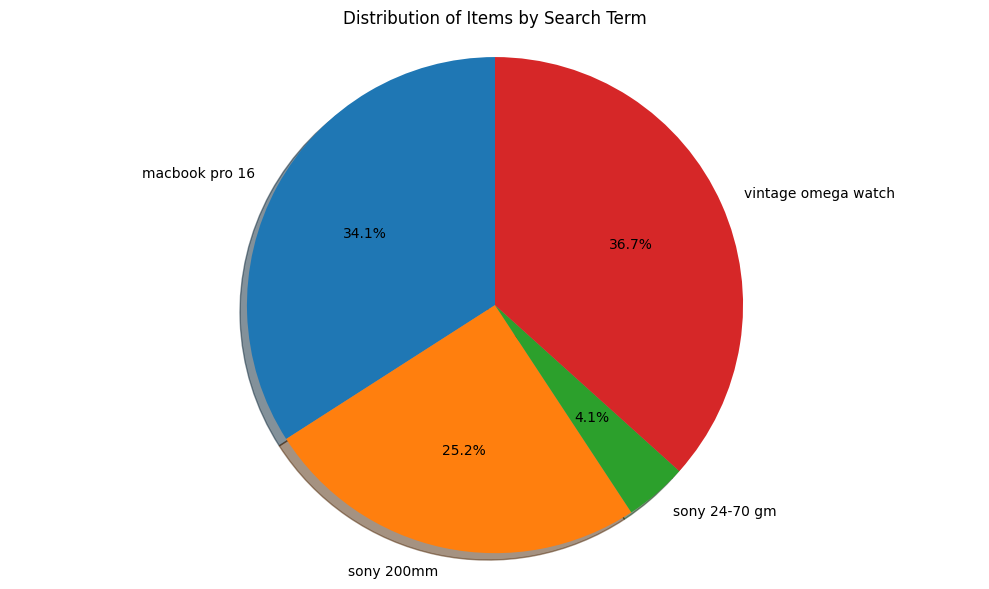

Error generating dashboard: Execution failed on sql '
    SELECT 
        p.title, 
        p.current_price, 
        p.timestamp, 
        p.search_term
    FROM 
        product_prices p
    JOIN 
        products pr ON p.product_link = pr.link
    ORDER BY 
        p.timestamp
    ': no such table: product_prices
Falling back to sample visualizations...


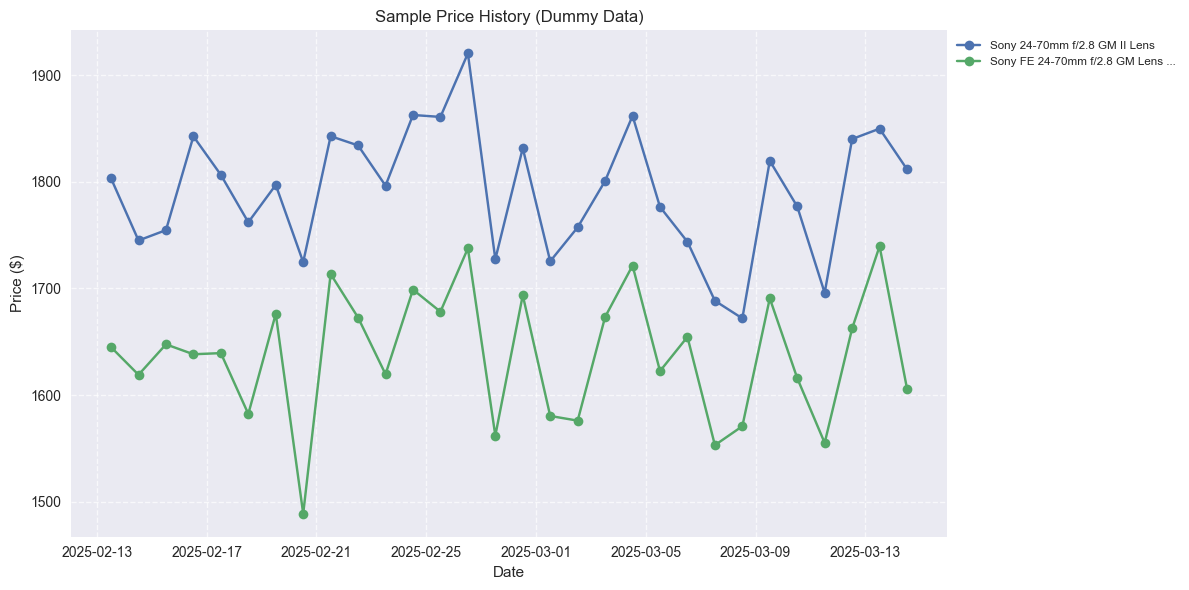

In [32]:
def generate_basic_stats():
    """Generate basic statistics about the tracked items"""
    conn = sqlite3.connect('ebay_auction_tracker.db')
    cursor = conn.cursor()
    
    # Get count of unique items
    cursor.execute("SELECT COUNT(*) FROM items")
    item_count = cursor.fetchone()[0]
    
    # Get count of observations
    cursor.execute("SELECT COUNT(*) FROM observations")
    observation_count = cursor.fetchone()[0]
    
    # Get count of search terms
    cursor.execute("SELECT COUNT(DISTINCT search_term) FROM items")
    search_term_count = cursor.fetchone()[0]
    
    # Get items with price changes
    cursor.execute('''
    SELECT COUNT(*) FROM (
        SELECT i.item_id
        FROM items i
        JOIN observations o ON i.item_id = o.item_id
        GROUP BY i.item_id
        HAVING COUNT(DISTINCT o.price_numeric) > 1
    )
    ''')
    items_with_price_changes = cursor.fetchone()[0]
    
    # Get average price by search term
    cursor.execute('''
    SELECT i.search_term, AVG(o.price_numeric) as avg_price
    FROM items i
    JOIN observations o ON i.item_id = o.item_id
    WHERE o.price_numeric IS NOT NULL
    GROUP BY i.search_term
    ''')
    avg_prices = cursor.fetchall()
    
    conn.close()
    
    # Print summary statistics
    print("======= eBay Auction Tracker Statistics =======")
    print(f"Total Items Tracked: {item_count}")
    print(f"Total Observations: {observation_count}")
    print(f"Number of Search Terms: {search_term_count}")
    print(f"Items with Price Changes: {items_with_price_changes}")
    print("\nAverage Price by Search Term:")
    for term, avg in avg_prices:
        print(f"  {term}: ${avg:.2f}")
    print("=============================================")
    
    # Create a pie chart of items by search term
    conn = sqlite3.connect('ebay_auction_tracker.db')
    query = "SELECT search_term, COUNT(*) as count FROM items GROUP BY search_term"
    search_term_counts = pd.read_sql_query(query, conn)
    conn.close()
    
    plt.figure(figsize=(10, 6))
    plt.pie(search_term_counts['count'], labels=search_term_counts['search_term'], autopct='%1.1f%%',
            shadow=True, startangle=90)
    plt.axis('equal')
    plt.title('Distribution of Items by Search Term')
    plt.tight_layout()
    plt.show()

def auction_status_summary():
    """Generate summary of auction statuses"""
    conn = sqlite3.connect('ebay_auction_tracker.db')
    
    # Check if auction_status column exists in the observations table
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(observations)")
    columns = [info[1] for info in cursor.fetchall()]
    
    if 'auction_status' not in columns:
        print("Auction status information not available in the database")
        conn.close()
        return
    
    # Query for auction status
    query = """
    SELECT 
        i.search_term,
        o.auction_status,
        COUNT(*) as count
    FROM 
        observations o
    JOIN 
        items i ON o.item_id = i.item_id
    WHERE
        o.auction_status IS NOT NULL
    GROUP BY
        i.search_term, o.auction_status
    """
    
    status_df = pd.read_sql_query(query, conn)
    conn.close()
    
    if len(status_df) == 0:
        print("No auction status data available")
        return
    
    # Create a grouped bar chart
    plt.figure(figsize=(12, 6))
    
    # Pivot the data for plotting
    pivot_df = status_df.pivot_table(
        index='search_term',
        columns='auction_status',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    
    pivot_df.plot(kind='bar', stacked=True)
    plt.title('Auction Status by Search Term')
    plt.xlabel('Search Term')
    plt.ylabel('Count')
    plt.legend(title='Auction Status')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def item_price_history(item_id=None):
    """
    Generate price history chart for a specific item
    
    Args:
        item_id: ID of the item to visualize (if None, user will be prompted)
    """
    conn = sqlite3.connect('ebay_auction_tracker.db')
    
    if item_id is None:
        # Get list of items with most observations
        query = """
        SELECT 
            i.item_id, 
            i.first_seen_title as title,
            COUNT(*) as observation_count
        FROM 
            items i
        JOIN 
            observations o ON i.item_id = o.item_id
        GROUP BY 
            i.item_id
        ORDER BY 
            observation_count DESC
        LIMIT 20
        """
        
        items_df = pd.read_sql_query(query, conn)
        
        print("Top items with most observations:")
        for idx, row in items_df.iterrows():
            print(f"{idx+1}. {row['title']} (ID: {row['item_id']}, Observations: {row['observation_count']})")
        
        try:
            selection = int(input("\nEnter the number of the item to visualize (1-20): "))
            if 1 <= selection <= len(items_df):
                item_id = items_df.iloc[selection-1]['item_id']
            else:
                print("Invalid selection. Using the first item.")
                item_id = items_df.iloc[0]['item_id']
        except ValueError:
            print("Invalid input. Using the first item.")
            item_id = items_df.iloc[0]['item_id']
    
    # Get item details
    cursor = conn.cursor()
    cursor.execute("SELECT first_seen_title FROM items WHERE item_id = ?", (item_id,))
    item_title = cursor.fetchone()[0]
    
    # Get price history
    query = """
    SELECT 
        o.timestamp, 
        o.price_numeric,
        o.bid_count_numeric
    FROM 
        observations o
    WHERE 
        o.item_id = ?
    ORDER BY 
        o.timestamp
    """
    
    history_df = pd.read_sql_query(query, conn, params=(item_id,))
    conn.close()
    
    # Convert timestamp to datetime
    history_df['timestamp'] = pd.to_datetime(history_df['timestamp'])
    
    if len(history_df) == 0:
        print(f"No price history data available for item ID: {item_id}")
        return
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot price history
    ax1.plot(history_df['timestamp'], history_df['price_numeric'], marker='o', linestyle='-', color='blue')
    ax1.set_title(f'Price History for "{item_title}" (ID: {item_id})')
    ax1.set_ylabel('Price ($)')
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot bid count if available
    if 'bid_count_numeric' in history_df.columns and history_df['bid_count_numeric'].notna().any():
        ax2.plot(history_df['timestamp'], history_df['bid_count_numeric'], marker='s', linestyle='-', color='green')
        ax2.set_ylabel('Number of Bids')
    else:
        ax2.text(0.5, 0.5, 'No bid data available', ha='center', va='center', transform=ax2.transAxes)
    
    ax2.set_xlabel('Date')
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Format x-axis date
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

def generate_dashboard():
    """Generate a comprehensive dashboard with all visualizations"""
    print("Generating eBay Auction Tracker Dashboard...")
    
    try:
        # Generate basic statistics
        generate_basic_stats()
        
        # Generate visualizations
        price_history_chart()  
        price_distribution_boxplot()
        search_term_comparison()
        price_trend_analysis()
        
        # Try to generate bid count analysis and price heatmap
        try:
            bid_count_analysis()
        except Exception as e:
            print(f"Could not generate bid count analysis: {e}")
        
        try:
            price_heatmap()
        except Exception as e:
            print(f"Could not generate price heatmap: {e}")
            
        try:
            auction_status_summary()
        except Exception as e:
            print(f"Could not generate auction status summary: {e}")
        
    except Exception as e:
        print(f"Error generating dashboard: {e}")
        print("Falling back to sample visualizations...")
        
        # Create sample data
        search_terms = ["sony 24-70 gm", "vintage omega watch", "macbook pro 16"]
        start_date = datetime.now() - timedelta(days=30)
        dates = [start_date + timedelta(days=i) for i in range(30)]
        
        data = []
        
        # Sample data for Sony lens
        sony_base_price = 1800
        for date in dates:
            price = sony_base_price + np.random.normal(0, 50)
            data.append({
                'title': 'Sony 24-70mm f/2.8 GM II Lens',
                'current_price': price,
                'timestamp': date,
                'search_term': 'sony 24-70 gm'
            })
            data.append({
                'title': 'Sony FE 24-70mm f/2.8 GM Lens SEL2470GM',
                'current_price': price - 150 + np.random.normal(0, 30),
                'timestamp': date,
                'search_term': 'sony 24-70 gm'
            })
        
        # Create DataFrame
        sample_df = pd.DataFrame(data)
        
        # Plot using the sample data
        with plt.style.context('seaborn-v0_8'):
            plt.figure(figsize=(12, 6))
            
            # Group by search term and title
            for term, term_group in sample_df.groupby('search_term'):
                for title, group in term_group.groupby('title'):
                    short_title = title[:30] + '...' if len(title) > 30 else title
                    plt.plot(group['timestamp'], group['current_price'], marker='o', linestyle='-', label=short_title)
            
            plt.title('Sample Price History (Dummy Data)')
            plt.xlabel('Date')
            plt.ylabel('Price ($)')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
            plt.tight_layout()
            plt.show()

# Examples of how to use these visualization functions
print("Visualization functions available:")
print("1. price_history_chart(search_term=None) - Line chart of price history")
print("2. price_distribution_boxplot() - Box plots of price distribution")
print("3. price_heatmap() - Heatmap of price changes")
print("4. search_term_comparison() - Bar chart comparing search terms")
print("5. price_trend_analysis() - Price trends with trend lines")
print("6. bid_count_analysis() - Analysis of bid counts")
print("7. item_price_history(item_id=None) - Detailed history for specific item")
print("8. auction_status_summary() - Summary of auction statuses")
print("9. generate_basic_stats() - Basic statistics")
print("10. generate_dashboard() - Run all visualizations")


generate_dashboard()